In [142]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import numba as nb
import time
from scipy.optimize import least_squares

In [143]:
#define objective function and jacobian
@nb.njit()
def func(tau_t, data, freq, weights):
    ''' 
    Get residuals for given tau at single time sample, for all blines

    Notes:
    - we set the reference antenna to zero delay: all other ants are with respect to it
    - therefore tau_t has length nant-1
    - residuals is 1D, and splits real and imag residuals up for fitting
    - convention is that timing difference is ai-aj
    '''
    # for one time sample
    nant= 2
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    residuals = np.zeros((2 * n_eval,), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                y = np.exp(1j * pred) - np.exp(1j*data[rowidx])
                residuals[rowidx] = w * np.real(y)
                residuals[rowidx + n_eval] = w * np.imag(y)
                blnum += 1
    return residuals

@nb.njit()
def jac(tau_t, data, freq, weights):
    '''
    Get the Jacobian for given tau at single time sample, for all blines

    Notes:
    - Antenna 0 is the reference so its delay is zero
    - therefore tau_t has length nant-1
    '''
    nant= 2
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    J = np.zeros((2 * n_eval, nant-1), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, aj - 1] = -im
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, ai - 1] = re
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, ai - 1] = im
                    J[rowidx + n_eval, aj - 1] = -im
                blnum += 1
    return J

Text(0.5, 0.98, 'Initial Visibility Phase')

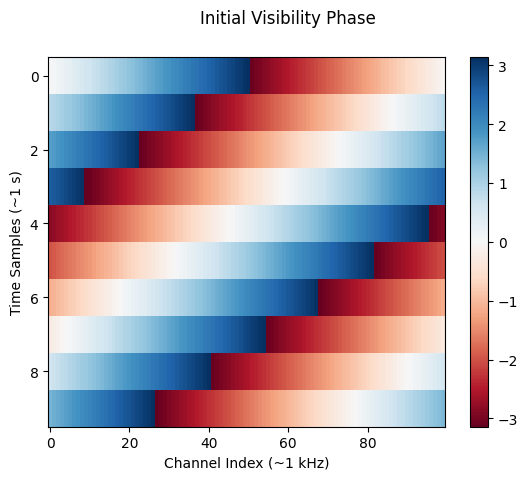

In [159]:
delays = 10000 + np.arange(10)*1 #delays in ns
freqs = 137e-3 + np.arange(100)*1e-6   #frequencies in GHz
phase = np.angle(np.exp(1j*2*np.pi*delays[:,None]*freqs[None,:]))
ntimes = len(delays)
nant = 2
nbl = 1

fig, ax = plt.subplots()
im = ax.imshow(phase, aspect='auto', cmap='RdBu', interpolation='none',vmin=-np.pi, vmax=np.pi)
cbar=plt.colorbar(im,ax=ax)
ax.set_ylabel('Time Samples (~1 s)')
ax.set_xlabel('Channel Index (~1 kHz)')
fig.suptitle('Initial Visibility Phase')

In [160]:
freq_carrier = freqs[40]
carrier_2pi = 1/freq_carrier
carrier_pi = carrier_2pi/2
print(carrier_pi)

3.648569760653823


In [161]:
weights = np.array([1], dtype='float64')
tau_trials = np.linspace(-40000, 40000, 1000001)
cost = np.zeros(len(tau_trials))

print(phase.shape)
print(weights.shape)
print(cost.shape)
print(tau_trials.shape)

(10, 100)
(1,)
(1000001,)
(1000001,)


Text(0.5, 1.0, 'Zoomed Cost Surface')

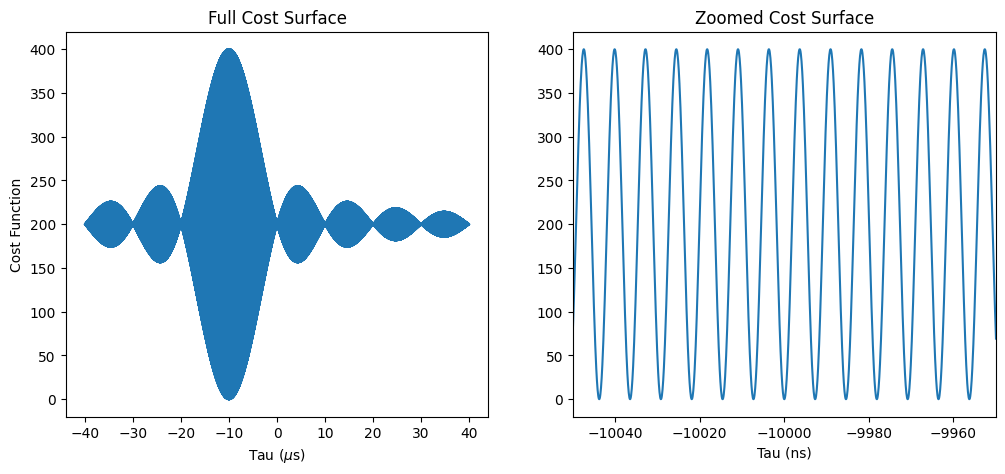

In [162]:
#check the phase space
for i in range(len(tau_trials)):
    tau = np.array([tau_trials[i]])
    cost[i] = np.sum(func(tau, phase[0,:], freqs, weights)**2)

fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(tau_trials/1e3, cost)
ax[0].set_xlabel(r'Tau ($\mu$s)')
ax[0].set_ylabel('Cost Function')
ax[0].set_title('Full Cost Surface')

ax[1].plot(tau_trials, cost)
ax[1].set_xlim(-10050, -9950)
ax[1].set_xlabel('Tau (ns)')
ax[1].set_title('Zoomed Cost Surface')

(100,)


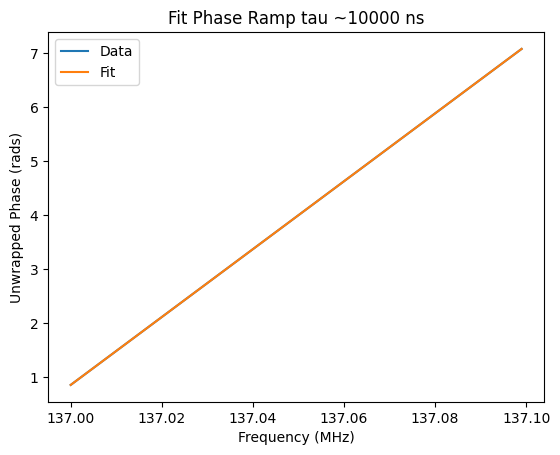

In [163]:
#make first initial guess about where we are
# (in future this will be a joint fit on all blines)

phase_sample = np.mean(np.unwrap(phase[:3,:], axis=1), axis=0)
print(phase_sample.shape)
m, c = np.polyfit(freqs, phase_sample, deg=1)
tau_guess0 = m/(2*np.pi)

plt.plot(freqs*1e3, phase_sample, label='Data')
plt.plot(freqs*1e3, m*freqs+c, label='Fit')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Unwrapped Phase (rads)')
plt.title(f'Fit Phase Ramp tau ~{int(tau_guess0)} ns')
plt.legend()

In [164]:
#use guess to fit for all delays

taus_fitted = np.zeros((ntimes,nant-1),dtype='float64')
taus_guess = -tau_guess0 #beware convention here!!
print('Starting guess tau', tau_guess[0])
for tt in range(ntimes):
    ydata = phase[tt,:].ravel()
    t1=time.time()
    tau_fit_params = least_squares(func, taus_guess, args=(ydata, freqs, weights),
                                                        jac=jac,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')
    t2=time.time()
    taus_fitted[tt,:] = tau_fit_params['x']
    tau_guess = tau_fit_params['x']

    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    print('new guess:', tau_guess[0])

Starting guess tau -9997.203366626965
done tt=0, time = 0.000
new guess: -10000.000000000002
done tt=1, time = 0.000
new guess: -10001.0
done tt=2, time = 0.000
new guess: -10002.0
done tt=3, time = 0.000
new guess: -10003.0
done tt=4, time = 0.000
new guess: -10003.999999996851
done tt=5, time = 0.000
new guess: -9997.703366626965
done tt=6, time = 0.000
new guess: -9998.70336662702
done tt=7, time = 0.000
new guess: -9999.703366628395
done tt=8, time = 0.000
new guess: -10000.703366632579
done tt=9, time = 0.000
new guess: -10001.703366625648


Text(0, 0.5, 'Tau (ns)')

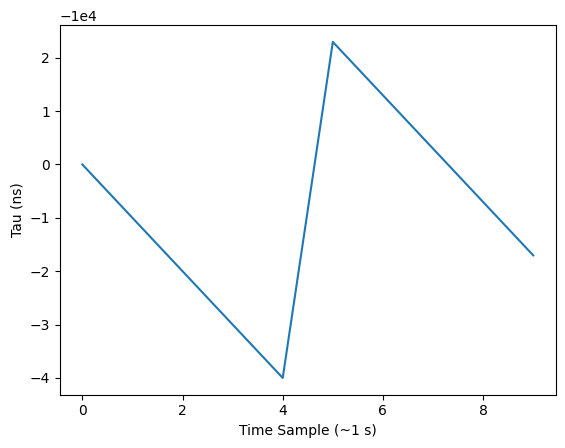

In [166]:
plt.plot(taus_fitted)
plt.xlabel('Time Sample (~1 s)')
plt.ylabel('Tau (ns)')